In [ ]:
import platform
from pathlib import Path

# Detect OS and set data root
os_name = platform.system()

if os_name == "Windows":
    DATA_ROOT = Path("Z:/")
elif os_name == "Darwin":  # macOS
    DATA_ROOT = Path("/Volumes/classdata/")
elif os_name == "Linux":
    DATA_ROOT = Path("/mnt/classdata/")
else:
    raise RuntimeError(f"Unsupported OS: {os_name}")


if __name__ == '__main__':
    print(DATA_ROOT)

In [ ]:
from flovopy.utils.misc import tree
print(f"DATA_ROOT is set to: {DATA_ROOT}")
tree(DATA_ROOT, max_depth=0, dirs_only=True)

In [ ]:
from pathlib import Path
KSC_ROOT = DATA_ROOT / "KSC/20260310_service/20_archive/SDS/"
#SDS_MVO_ROOT = Path('~').expanduser() / 'work' / 'SDS'
#tree(KSC_ROOT)

In [ ]:
from flovopy.enhanced.sdsclient import EnhancedSDSClient
from obspy.core import UTCDateTime
startTime = UTCDateTime(2026, 2, 5)   # start date (inclusive)
endTime   = UTCDateTime(2026, 2, 8)  # end date (exclusive)

# -----------------------------------------------------------------------------
# Initialize SDS client (points to your SDS archive on disk)
# -----------------------------------------------------------------------------
mySDSclient = EnhancedSDSClient(KSC_ROOT)

#availdf, ids = mySDSclient.get_availability(startday=startTime, endday=endTime, verbose=True)
#display(availdf)

In [ ]:
# Generate a clipping tool
import numpy as np
def clip_trace(trace, percentile=99.9):
    '''
    Clip the data in this Trace to +/- 2x the given percentile of the absolute value of the data.
    '''
    x = trace.data
    clip_level = np.nanpercentile(np.abs(x), percentile) * 2
    print(f"Clipping {trace.id} at {clip_level:.2f}")
    trace.data = np.clip(trace.data, -clip_level, clip_level)

def clip_stream(stream, percentile=99.9):
    for tr in stream:
        clip_trace(tr, percentile=percentile)

In [36]:
import numpy as np
import pandas as pd
from scipy.ndimage import binary_dilation
from obspy import Stream


def nan_safe_moving_median(x, nwin, min_fraction=0.5):
    """
    Centered moving median that ignores NaNs.

    Returns NaN where there are not enough finite samples.
    """
    min_periods = max(1, int(min_fraction * nwin))

    return (
        pd.Series(x)
        .rolling(window=nwin, center=True, min_periods=min_periods)
        .median()
        .to_numpy()
    )


def remove_moving_median_and_mask_steps_nan_safe(
    x,
    fs,
    median_window_sec=1.0,
    threshold_sigma=8.0,
    mask_expand_sec=0.3,
    min_abs_change=None,
    max_mask_fraction=0.25,
    min_fraction=0.5,
    fill_value=np.nan,
):
    """
    NaN-safe moving-median baseline removal and ramp/step masking.

    This preserves existing NaNs and avoids filling gaps with artificial values.
    """

    # Convert masked arrays to regular arrays with NaNs
    if np.ma.isMaskedArray(x):
        x = x.filled(np.nan)
    else:
        x = np.asarray(x, dtype=float)

    original_nan_mask = ~np.isfinite(x)

    nwin = int(round(median_window_sec * fs))
    if nwin < 3:
        nwin = 3
    if nwin % 2 == 0:
        nwin += 1

    # 1. NaN-safe moving median
    baseline = nan_safe_moving_median(
        x,
        nwin=nwin,
        min_fraction=min_fraction,
    )

    # 2. Difference of baseline
    db = np.diff(baseline, prepend=baseline[0])

    # Only use finite baseline differences
    finite_db = db[np.isfinite(db)]

    if len(finite_db) == 0:
        y = x - baseline
        return y, baseline, original_nan_mask.copy()

    # 3. Robust scale estimate
    med_db = np.nanmedian(finite_db)
    scale = 1.4826 * np.nanmedian(np.abs(finite_db - med_db))

    if not np.isfinite(scale) or scale == 0:
        scale = np.nanstd(finite_db)

    if not np.isfinite(scale) or scale == 0:
        step_mask = np.zeros_like(x, dtype=bool)
    else:
        threshold = threshold_sigma * scale

        if min_abs_change is not None:
            threshold = max(threshold, min_abs_change)

        step_mask = np.abs(db) > threshold
        step_mask[~np.isfinite(db)] = False

    # 4. Expand mask around transitions
    nexpand = int(round(mask_expand_sec * fs))
    if nexpand > 0:
        structure = np.ones(2 * nexpand + 1, dtype=bool)
        step_mask = binary_dilation(step_mask, structure=structure)

    # 5. Safety guard: do not allow noisy traces to become all NaNs
    mask_fraction = np.mean(step_mask)

    if mask_fraction > max_mask_fraction:
        print(
            f"Warning: step mask covers {100 * mask_fraction:.1f}% of trace. "
            "Disabling step mask for this trace."
        )
        step_mask[:] = False

    # 6. Remove baseline
    y = x - baseline

    # 7. Preserve original NaNs and mask ramp/step sections
    final_mask = original_nan_mask | step_mask | ~np.isfinite(baseline)
    y[final_mask] = fill_value

    return y, baseline, final_mask

def remove_moving_median_from_stream(st):
    st2 = Stream()
    for tr in st:
        print(f'Median detrending {tr.id}')

        y, baseline, mask = remove_moving_median_and_mask_steps_nan_safe(
            tr.data,
            fs=tr.stats.sampling_rate,
            median_window_sec=1.0,
            threshold_sigma=8.0,
            mask_expand_sec=0.3,
            min_abs_change=None,
            max_mask_fraction=0.25,
        )

        tr_corrected = tr.copy()
        tr_corrected.data = y
        st2.append(tr_corrected)
    return st2

RMS Save Path:  /Users/glennthompson/KSC_Data_Analysis
Raw data:


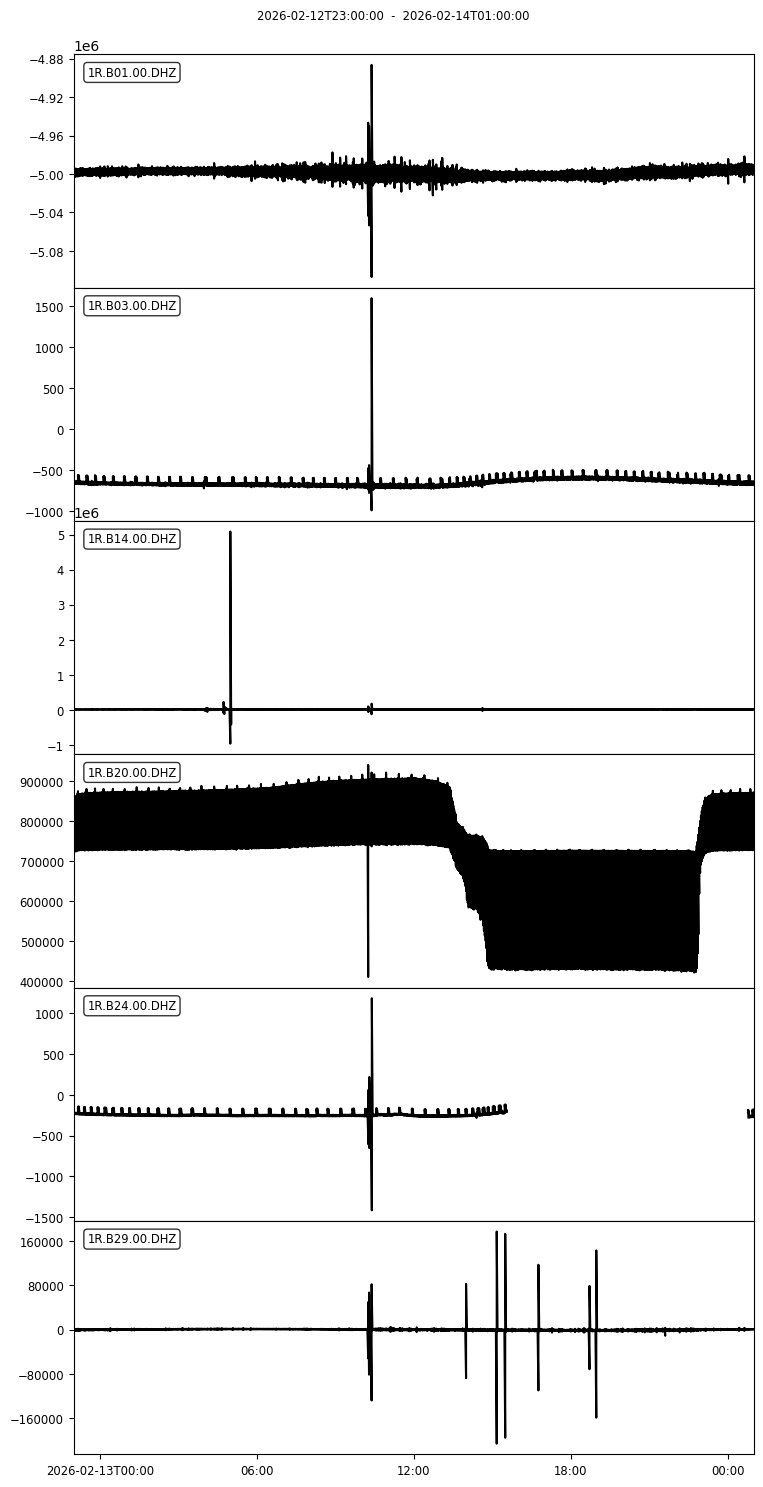

removing moving median


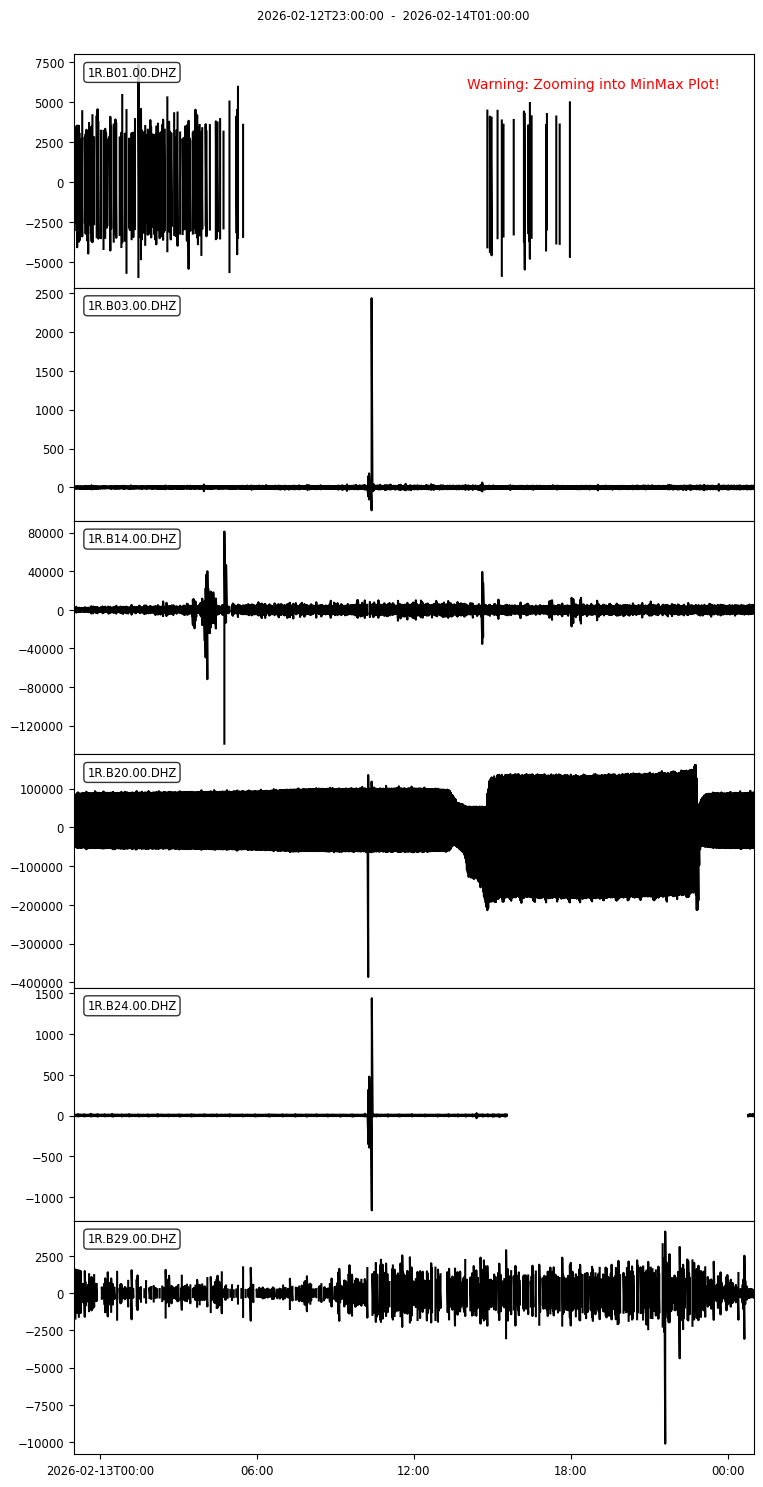

Filled in gaps


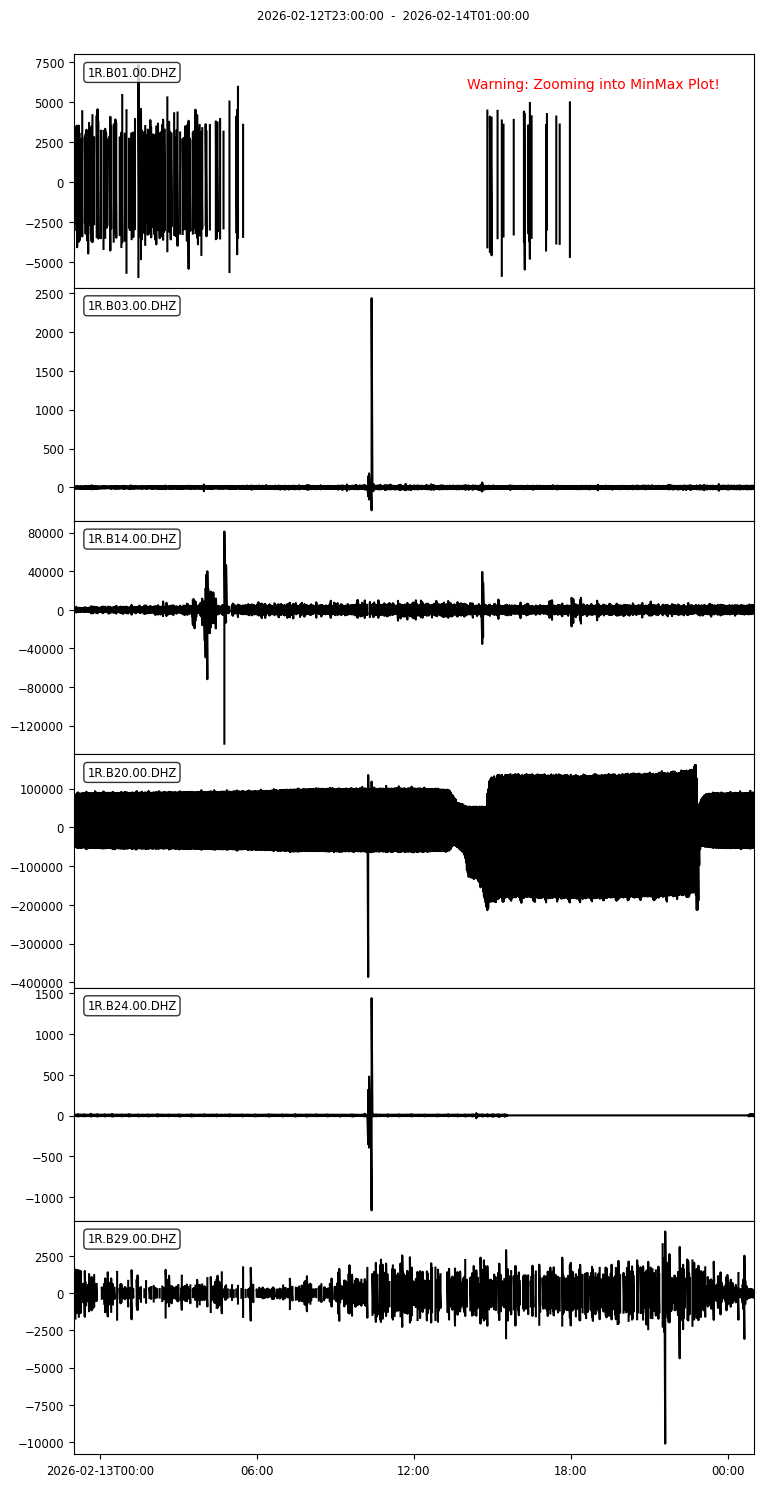

Removed DC offset


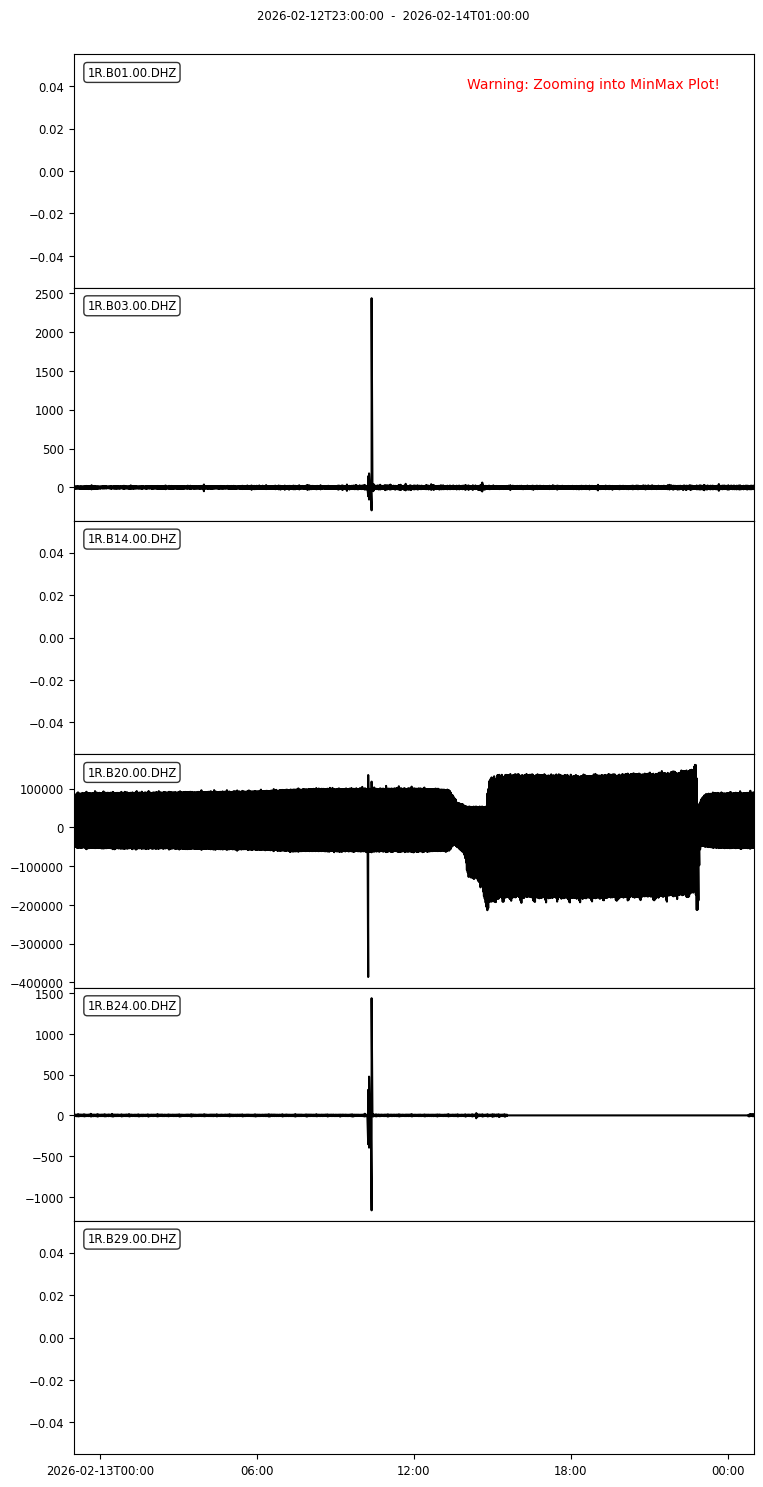

Tapered Edges


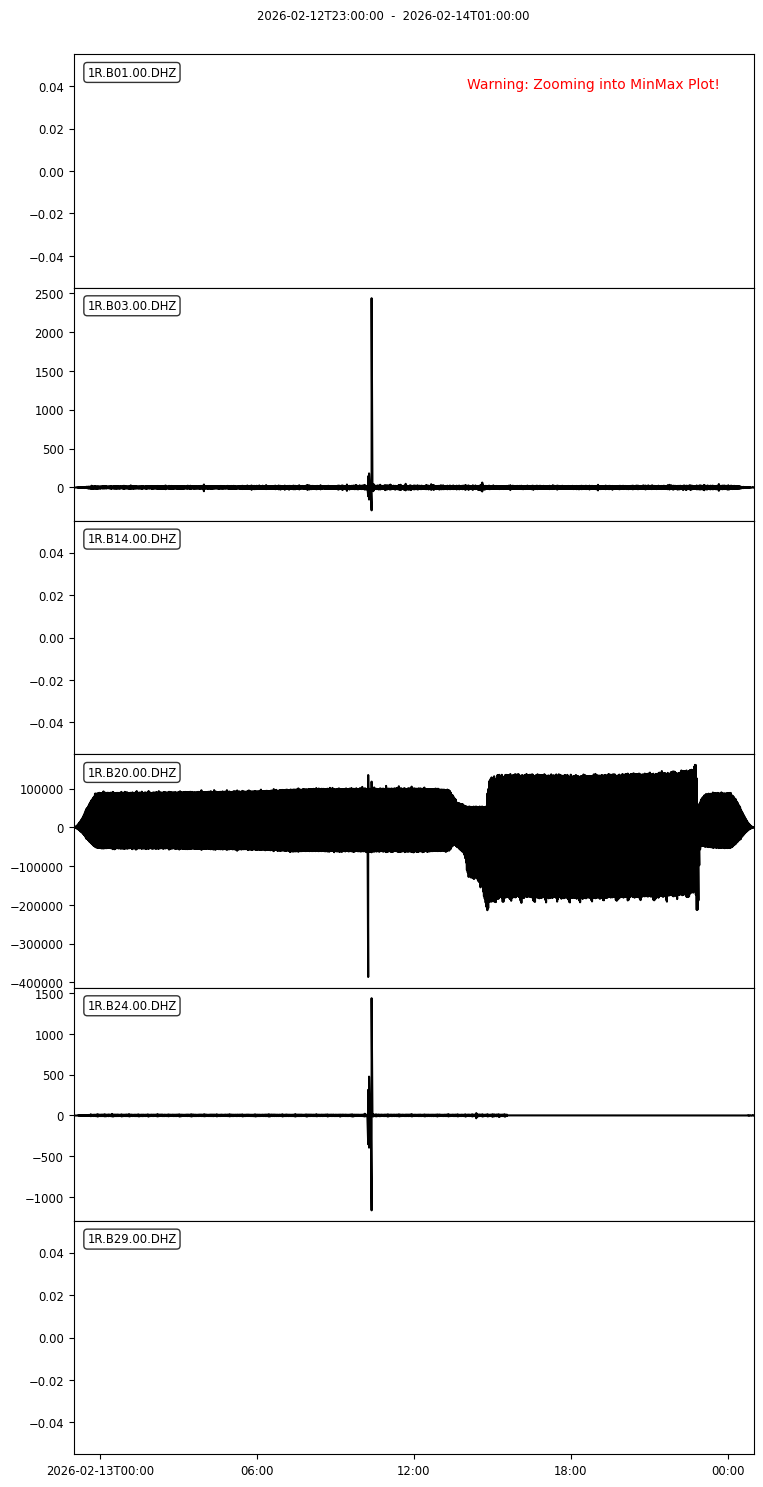

Applied High Pass Filter


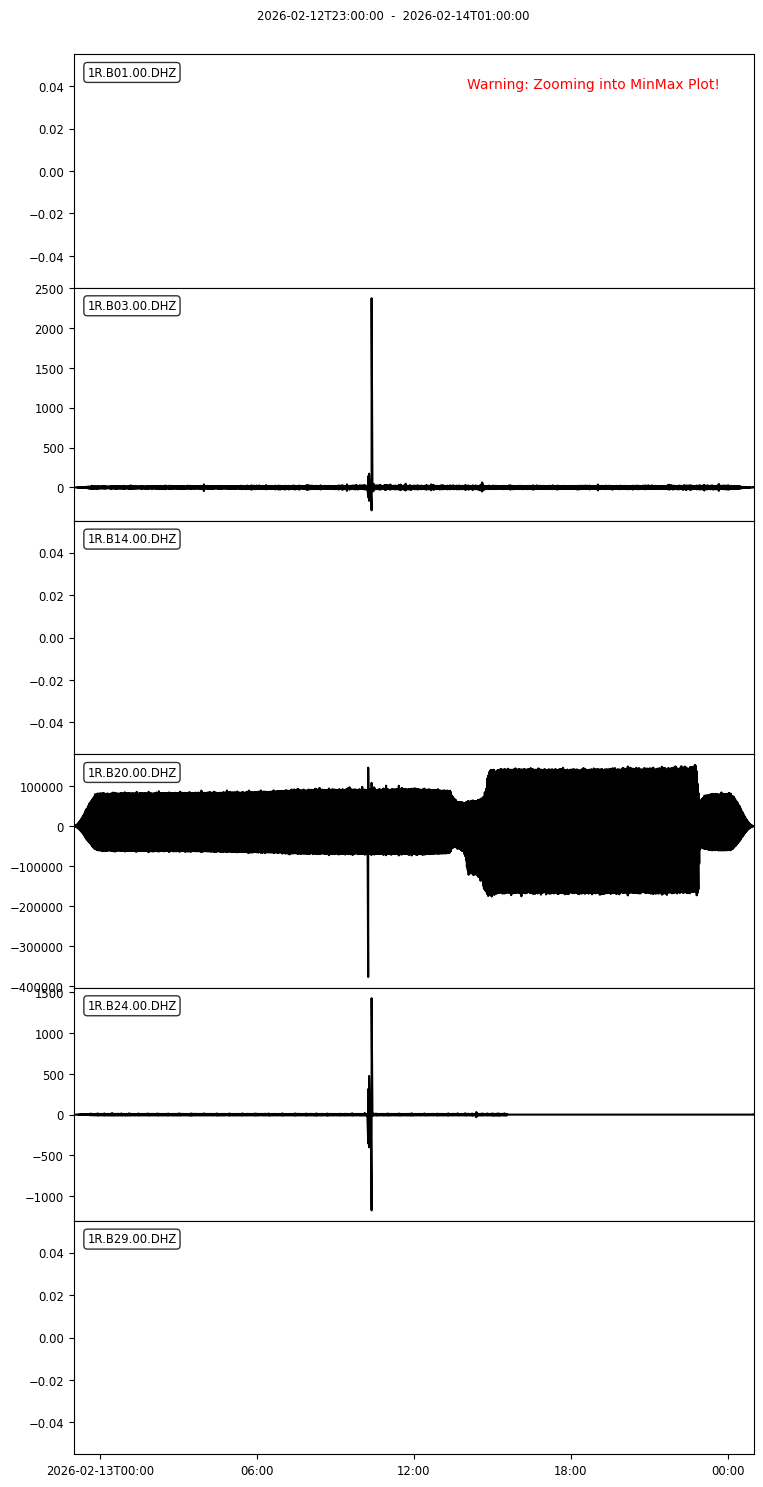

Trimmed data


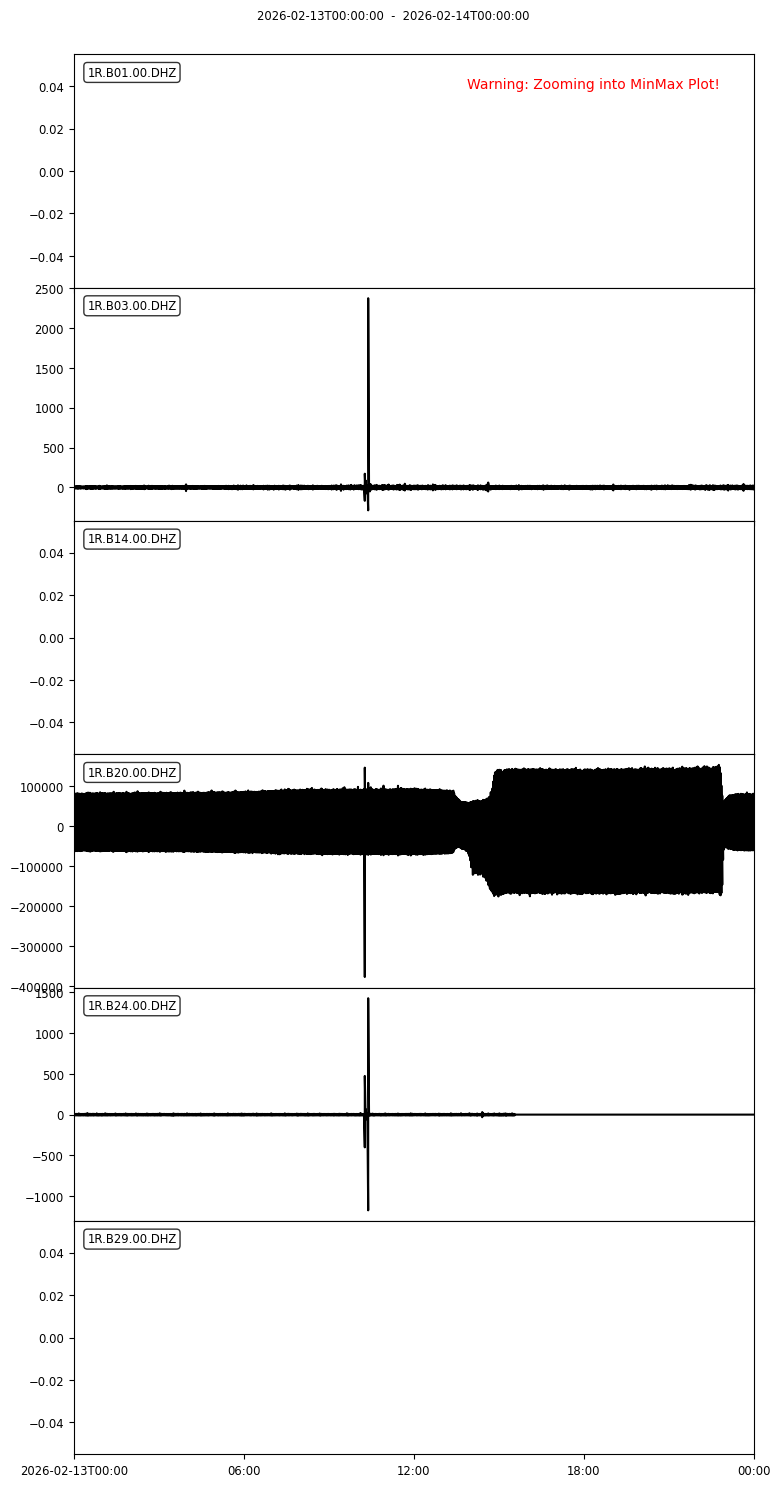

/Users/glennthompson/Developer/flovopy/flovopy/processing/sam.py:282: RuntimeWarning: All-NaN slice encountered
  df['min']    = pd.Series(np.nanmin(Y, axis=1))
/Users/glennthompson/Developer/flovopy/flovopy/processing/sam.py:283: RuntimeWarning: Mean of empty slice
  df['mean']   = pd.Series(np.nanmean(Y, axis=1))
/Users/glennthompson/Developer/flovopy/flovopy/processing/sam.py:284: RuntimeWarning: All-NaN slice encountered
  df['max']    = pd.Series(np.nanmax(Y, axis=1))
/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1216: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/glennthompson/Developer/flovopy/flovopy/processing/sam.py:282: RuntimeWarning: All-NaN slice encoun

RSAM object:
Number of SEED ids: 6 [['1R.B24.00.DHZ', '1R.B01.00.DHZ', '1R.B03.00.DHZ', '1R.B14.00.DHZ', '1R.B20.00.DHZ', '1R.B29.00.DHZ']]
Number of rows: 1440
Start time: 2026-02-13T00:00:00.000000Z
End time: 2026-02-14T00:00:00.000000Z
Duration: 86400.0 s
Sampling interval: 60.0 s
Metrics: min, mean, max, median, rms, VLP, LP, VT, fratio
1R.B24.00.DHZ: median=0.905
1R.B01.00.DHZ: median=nan
1R.B03.00.DHZ: median=1.53
1R.B14.00.DHZ: median=nan
1R.B20.00.DHZ: median=3.29e+03
1R.B29.00.DHZ: median=nan
METRIC: mean
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'


/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


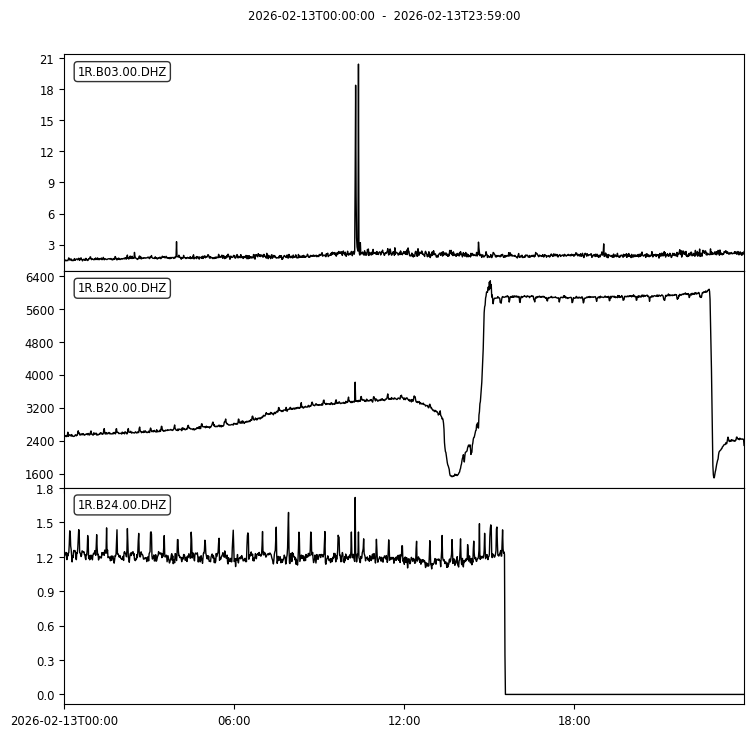

METRIC: median
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'


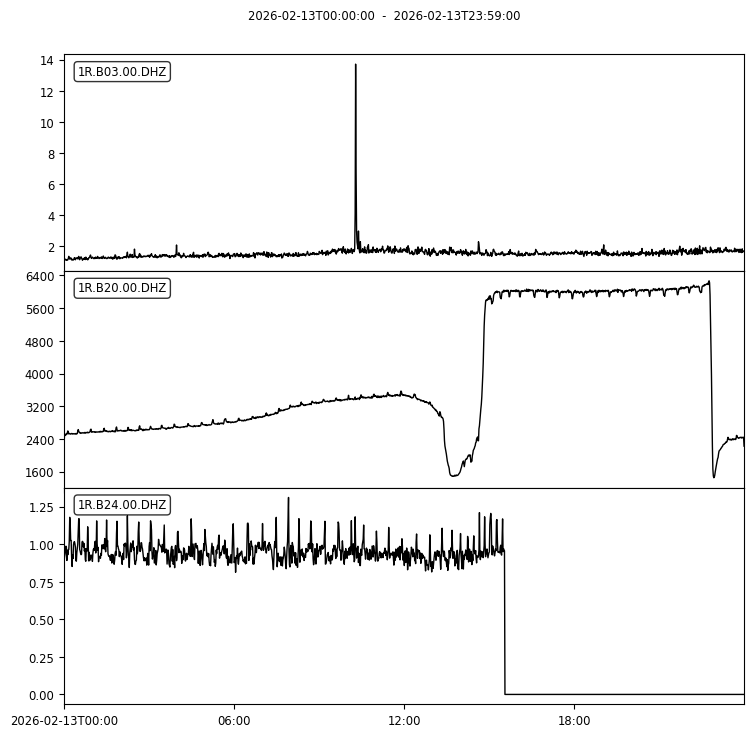

METRIC: rms
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'


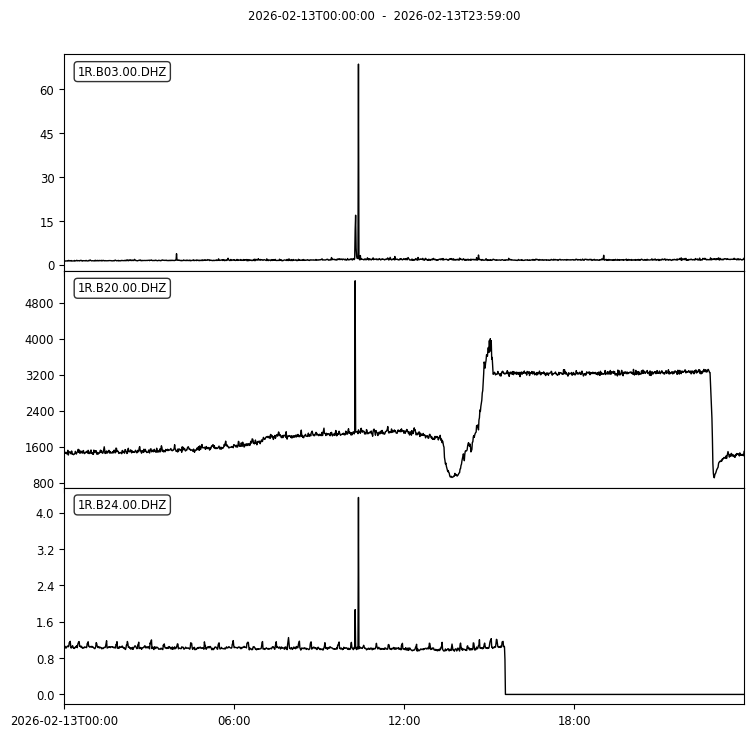

METRIC: max
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'


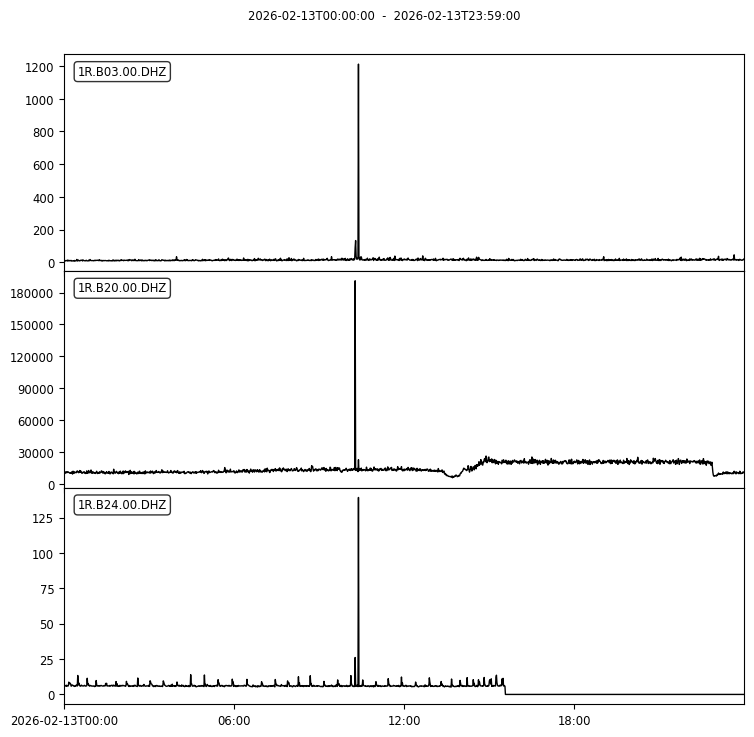

METRIC: LP
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'


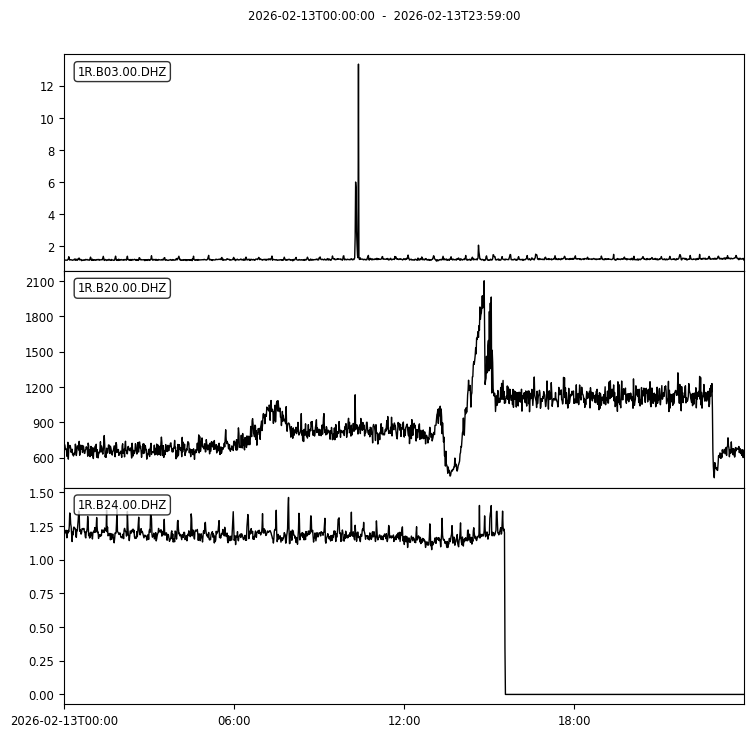

METRIC: VT
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'


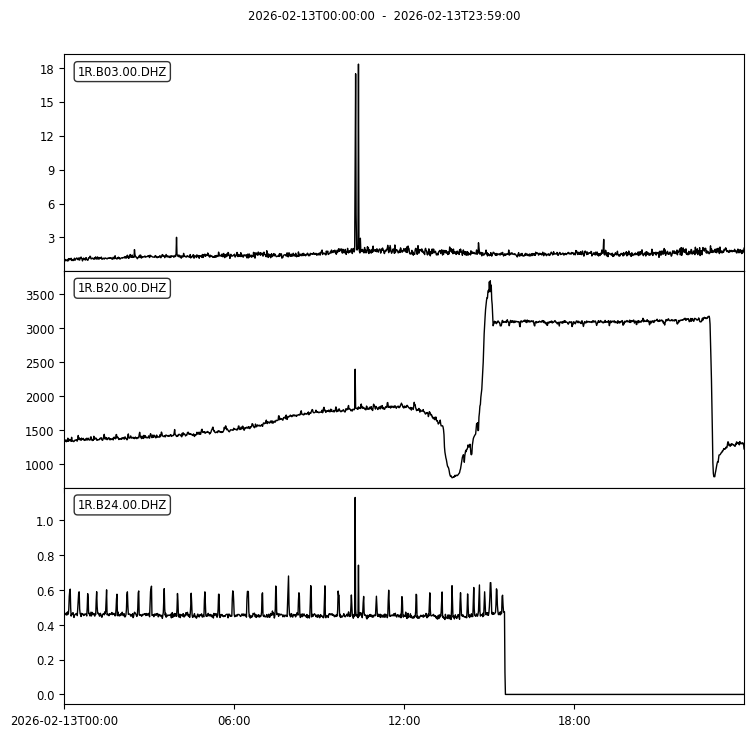

METRIC: fratio
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 1440 rows is already on a regular 60 s grid based on column 'time'


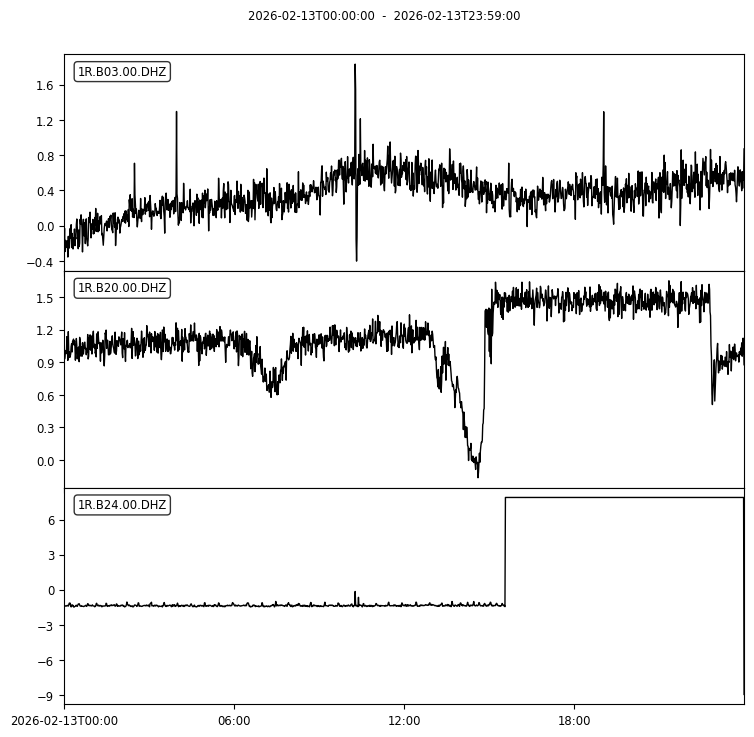

In [35]:
from flovopy.processing.sam import RSAM # RSAM class from flovopy
from flovopy.enhanced.sdsclient import EnhancedSDSClient
from obspy.core import UTCDateTime, Stream
import numpy as np
from pathlib import Path
# General Information
NET = "1R"
STA = "B*"
LOC = "*"
CHA = "D*Z"

# Apply moving median detrend?
apply_moving_median=True

myRSAMSave = Path("~").expanduser() / "KSC_Data_Analysis"
myRSAMSave.mkdir(parents=True, exist_ok=True)
print("RMS Save Path: ",myRSAMSave)

# Analyze for each day
start_day =  UTCDateTime(2026, 2, 13)   # Initialize at start_day
end_day =  UTCDateTime(2026, 2, 14)

# Initialize day_start counter
day_start = start_day

# Initialize streams
#st = Stream() # create a master Stream object
#st2 = Stream()  # Initialize clipped stream object

import numpy as np


def fill_with_nanmedian(x):
    """
    Replace NaNs (and masked values) with the global nanmedian.

    Parameters
    ----------
    x : array-like or np.ma.MaskedArray

    Returns
    -------
    y : ndarray
        Regular NumPy array with gaps filled.
    median : float
        The value used for filling.
    """

    # Convert masked array → ndarray with NaNs
    if np.ma.isMaskedArray(x):
        data = x.filled(np.nan)
    else:
        data = np.asarray(x, dtype=float)

    # Compute median ignoring NaNs
    med = np.nanmedian(data)

    # Edge case: all values are NaN
    if not np.isfinite(med):
        raise ValueError("All values are NaN; cannot compute median.")

    # Fill NaNs
    y = np.where(np.isnan(data), med, data)

    return y, med

while day_start < end_day:
    day_start_wTaper = day_start - 60*60
    day_end = day_start + 86400
    day_end_wTaper = day_start + 86400+60*60  # 1 day
    st = mySDSclient.get_waveforms(NET, STA, LOC, CHA, day_start_wTaper, day_end_wTaper)
    
    print('Raw data:')
    st.plot(equal_scale=False);
    #st.write('rawdata.mseed')
    
    for tr in st:
        tr.data, med = fill_with_nanmedian(tr.data)
    
    # plot stream
    #print("My Sample Rate: ",tr.stats.sampling_rate)
    # remove best fit line
    if apply_moving_median:
        print('removing moving median')
        st2 = remove_moving_median_from_stream(st)
    else:
        st2 = st.copy()
        st2.detrend('linear')
        print("Data linear detrend")
    st2.plot(equal_scale=False);

    # fill gaps with last value
    st2.merge(method=1, fill_value='latest')
    print("Filled in gaps")
    st2.plot(equal_scale=False);

    # remove DC offset
    st2.detrend('constant')
    print("Removed DC offset")
    st2.plot(equal_scale=False);

    # taper edges (1 hour each side)
    st2.taper(max_percentage=1/26)
    print("Tapered Edges")
    st2.plot(equal_scale=False);

    # high-pass filter (short-period)
    st2.filter('highpass', freq=0.5)
    print("Applied High Pass Filter")
    st2.plot(equal_scale=False);

    # trim to the day of interest
    st2.trim(starttime=start_day, endtime=day_end)
    print("Trimmed data")
    st2.plot(equal_scale=False);

    # Calculate RSAM
    rsamObj = RSAM(stream=st2, sampling_interval=60) # 60-s sampling interval
    rsamObj.write(
        str(myRSAMSave),
        ext='csv',        # output format (csv files)
        overwrite=False    # overwrite existing files if present
    )
    print(rsamObj)
    rsamObj.plot(metrics=['mean','median','rms', 'max', 'LP', 'VT', 'fratio'])

    # Loop around
    day_start = day_end

In [ ]:
st.plot(equal_scale=False);

In [ ]:
# launch at 2026,2,13,10,15
st.plot(starttime=UTCDateTime(2026,2,12,10,10,0), endtime=UTCDateTime(2026,2,12,10,30,0), equal_scale=False);

In [ ]:
st5=st.copy()
st5.differentiate().plot(equal_scale=False);
#st5.plot(starttime=UTCDateTime(2026,2,12,10,10,0), endtime=UTCDateTime(2026,2,12,10,30,0), equal_scale=False);

In [ ]:
sti=st5.integrate().plot(equal_scale=False);

In [ ]:
st6=st5.copy()
st6.differentiate().plot(equal_scale=False);

In [ ]:
import numpy as np
from scipy.ndimage import median_filter, binary_dilation


def remove_moving_median_and_mask_steps(
    x,
    fs,
    median_window_sec=1.0,
    threshold_sigma=8.0,
    mask_expand_sec=0.25,
    use_mad=True,
    fill_value=np.nan,
):
    """
    Remove a moving-window median baseline and mask ramp/step transitions.

    Parameters
    ----------
    x : array-like
        1-D signal.
    fs : float
        Sampling rate in Hz.
    median_window_sec : float
        Length of moving median window in seconds.
    threshold_sigma : float
        Threshold for detecting rapid median changes.
    mask_expand_sec : float
        Expand detected transition regions by this many seconds on each side.
    use_mad : bool
        Use robust MAD estimate instead of standard deviation.
    fill_value : float
        Value used to null bad transition sections, usually np.nan.

    Returns
    -------
    y : ndarray
        Baseline-removed signal with transition sections nulled.
    baseline : ndarray
        Moving median baseline.
    mask : ndarray
        Boolean mask where transitions were detected.
    """

    x = np.asarray(x, dtype=float)

    nwin = int(round(median_window_sec * fs))
    if nwin < 3:
        nwin = 3
    if nwin % 2 == 0:
        nwin += 1

    # 1. Moving-window median baseline
    baseline = median_filter(x, size=nwin, mode="nearest")

    # 2. Difference of the moving median
    db = np.diff(baseline, prepend=baseline[0])

    # 3. Robust threshold for large median changes
    if use_mad:
        scale = 1.4826 * np.nanmedian(np.abs(db - np.nanmedian(db)))
    else:
        scale = np.nanstd(db)

    if not np.isfinite(scale) or scale == 0:
        mask = np.zeros_like(x, dtype=bool)
    else:
        mask = np.abs(db) > threshold_sigma * scale

    # 4. Expand mask around detected transition/ramp sections
    nexpand = int(round(mask_expand_sec * fs))
    if nexpand > 0:
        structure = np.ones(2 * nexpand + 1, dtype=bool)
        mask = binary_dilation(mask, structure=structure)

    # 5. Remove moving median everywhere
    y = x - baseline

    # 6. Null transition sections
    y[mask] = fill_value

    return y, baseline, mask

for tr in st:
    tr.plot(title='BEFORE')
    y, baseline, mask = remove_moving_median_and_mask_steps(
        tr.data,
        fs=tr.stats.sampling_rate,
        median_window_sec=1.0,
        threshold_sigma=8.0,
        mask_expand_sec=0.3,
    )

    tr_corrected = tr.copy()
    tr_corrected.data = y
    tr_corrected.plot(title='AFTER');